In [19]:
from pathlib import Path
import re

import pandas as pd

ROUND_NUMBER = 4
ROUND_FOLDER = Path(".")

DAY_RE  = re.compile(r"day_(-?\d+)\.csv$")
MARK_RE = re.compile(r"Mark\s+(\d+)", re.IGNORECASE)

# ── Prices ────────────────────────────────────────────────────────────────────
PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_LABELS, price_frames = [], []
for fp in PRICE_FILES:
    m = DAY_RE.search(fp.name)
    if not m:
        continue
    day = int(m.group(1))
    DAY_LABELS.append(day)
    df = pd.read_csv(fp, sep=";")
    df["day"]       = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    price_frames.append(df[["day", "timestamp", "product", "mid_price"]])

DAY_LABELS  = sorted(set(DAY_LABELS))
prices      = pd.concat(price_frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products    = sorted(plot_prices["product"].dropna().unique())

# Continuous x-axis with a visible gap between days
gap = 1000.0
x_offsets, separator_positions = {}, []
current_offset = 0.0
for day in DAY_LABELS:
    max_ts = float(plot_prices.loc[plot_prices["day"] == day, "timestamp"].max() or 0.0)
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_ts + gap / 2)
    current_offset += max_ts + gap

# ── Trades ────────────────────────────────────────────────────────────────────
TRADE_FILES = sorted(ROUND_FOLDER.glob(f"trades_round_{ROUND_NUMBER}_day_*.csv"))
trade_frames = []
for fp in TRADE_FILES:
    m = DAY_RE.search(fp.name)
    if not m:
        continue
    day = int(m.group(1))
    df = pd.read_csv(fp, sep=";")
    df["day"]       = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["price"]     = pd.to_numeric(df["price"],     errors="coerce")
    df["quantity"]  = pd.to_numeric(df["quantity"],  errors="coerce")
    trade_frames.append(df)

trades = pd.concat(trade_frames, ignore_index=True).dropna(subset=["timestamp", "price"])
trades["timestamp"] = trades["timestamp"].astype(float)
trades["x"] = trades["timestamp"] + trades["day"].map(x_offsets)

def _mark_id(name):
    m = MARK_RE.match(str(name))
    return int(m.group(1)) if m else None

trades["buyer_id"]  = trades["buyer"].apply(_mark_id)
trades["seller_id"] = trades["seller"].apply(_mark_id)

all_ids        = sorted(set(trades["buyer_id"].dropna().astype(int)) | set(trades["seller_id"].dropna().astype(int)))
min_id, max_id = int(min(all_ids)), int(max(all_ids))

print(f"Prices : {len(prices):,} rows | Products: {products}")
print(f"Trades : {len(trades):,} rows | Traders : Mark {min_id:02d} – Mark {max_id:02d}")


Prices : 360,000 rows | Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Trades : 4,281 rows | Traders : Mark 01 – Mark 67


In [17]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

TRADER_IDS = [1, 14, 22, 38, 49, 55, 67]

day_cmap  = plt.get_cmap("tab10")
color_map = {day: day_cmap(i % day_cmap.N) for i, day in enumerate(DAY_LABELS)}

n   = len(products)
out = widgets.Output()

def draw(active_ids):
    with out:
        clear_output(wait=True)
        if not active_ids:
            print("Select at least one trader.")
            return

        fig, axes = plt.subplots(n, 1, figsize=(16, max(4, 4 * n)), sharex=True)
        if n == 1:
            axes = [axes]

        for ax, product in zip(axes, products):
            pp = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

            for day in DAY_LABELS:
                dp = pp[pp["day"] == day].sort_values("timestamp")
                if dp.empty:
                    continue
                ax.plot(
                    dp["timestamp"] + x_offsets[day],
                    dp["mid_price"],
                    color=color_map[day], linewidth=1.6, label=f"Day {day}",
                )

            buy_added = sell_added = False
            for tid in active_ids:
                pt    = trades[trades["symbol"] == product]
                buys  = pt[pt["buyer_id"]  == tid]
                sells = pt[pt["seller_id"] == tid]

                if not buys.empty:
                    ax.scatter(
                        buys["x"], buys["price"],
                        marker="^", color="limegreen", edgecolors="darkgreen", linewidths=0.5,
                        s=buys["quantity"].clip(lower=1) * 10,
                        zorder=5, label="Buy" if not buy_added else "_nolegend_",
                    )
                    buy_added = True
                if not sells.empty:
                    ax.scatter(
                        sells["x"], sells["price"],
                        marker="v", color="red", edgecolors="darkred", linewidths=0.5,
                        s=sells["quantity"].clip(lower=1) * 10,
                        zorder=5, label="Sell" if not sell_added else "_nolegend_",
                    )
                    sell_added = True

            for sep in separator_positions[:-1]:
                ax.axvline(sep, color="black", linewidth=2)

            ax.set_title(product.replace("_", " "))
            ax.set_ylabel("price")
            ax.grid(alpha=0.25)
            ax.legend(loc="best", fontsize=7)
            ax.ticklabel_format(axis="y", style="plain", useOffset=False)

        axes[-1].set_xlabel("timestamp (concatenated across days)")
        names = ", ".join(f"Mark {i:02d}" for i in active_ids)
        fig.suptitle(f"Round {ROUND_NUMBER} · {names}", y=0.995)
        fig.tight_layout()
        display(fig)
        plt.close(fig)


checkboxes = {
    tid: widgets.Checkbox(
        value=(tid == TRADER_IDS[0]),
        description=f"Mark {tid:02d}",
        indent=False,
        layout=widgets.Layout(width="100px"),
    )
    for tid in TRADER_IDS
}

def on_change(_):
    draw([tid for tid, cb in checkboxes.items() if cb.value])

for cb in checkboxes.values():
    cb.observe(on_change, names="value")

box = widgets.HBox(
    list(checkboxes.values()),
    layout=widgets.Layout(flex_wrap="wrap"),
)
display(box, out)
draw([TRADER_IDS[0]])


Output()

In [13]:

# ── Unique Sellers per Day ────────────────────────────────────────────────────
seller_counts = (
    trades.dropna(subset=["buyer_id"])
    .groupby("day")["buyer_id"]
    .nunique()
    .rename("unique_buyers")
    .reset_index()
)
seller_counts["day"] = seller_counts["day"].apply(lambda d: f"Day {d}")

total = trades["buyer_id"].dropna().nunique()

print("┌─────────────────────────────┐")
print("│   Unique Seller IDs         │")
print("├──────────┬──────────────────┤")
print("│  Day     │  Unique Buyers  │")
print("├──────────┼──────────────────┤")
for _, row in seller_counts.iterrows():
    print(f"│  {row['day']:<7} │  {int(row['unique_buyers']):<16} │")
print("├──────────┼──────────────────┤")
print(f"│  Total   │  {total:<16} │")
print("└──────────┴──────────────────┘")


┌─────────────────────────────┐
│   Unique Seller IDs         │
├──────────┬──────────────────┤
│  Day     │  Unique Buyers  │
├──────────┼──────────────────┤
│  Day 1   │  7                │
│  Day 2   │  7                │
│  Day 3   │  7                │
├──────────┼──────────────────┤
│  Total   │  7                │
└──────────┴──────────────────┘


Seller IDs: 1 14 22 38 49 55 

Buyer IDs: 1 14 22 38 49 55 67

1: Good trader, buys a ton of otm options

14: Good trader

22: sells a ton

38: Bad trader of hydrogel

49: mainly sells velvetfruit

55: buy/sell VEV (bad)

67: Buy VEV

In [14]:

def compute_trader_pnl(trades_df=trades, prices_df=prices):
    """
    Returns a DataFrame with each trader's PnL per product per day.
    Positions are marked-to-market using the last mid_price of each day.

    Columns: trader_id, product, day, cash_pnl, position, mark_price,
             unrealized_pnl, total_pnl
    """
    records = []
    trader_ids = sorted(
        set(trades_df["buyer_id"].dropna().astype(int)) |
        set(trades_df["seller_id"].dropna().astype(int))
    )

    # Last mid price per (day, product) for mark-to-market
    last_mid = (
        prices_df.sort_values("timestamp")
        .groupby(["day", "product"])["mid_price"]
        .last()
    )

    for tid in trader_ids:
        buys  = trades_df[trades_df["buyer_id"]  == tid][["day", "symbol", "price", "quantity"]].copy()
        sells = trades_df[trades_df["seller_id"] == tid][["day", "symbol", "price", "quantity"]].copy()

        buys["signed_qty"]  =  buys["quantity"]
        buys["cash_flow"]   = -buys["price"] * buys["quantity"]

        sells["signed_qty"] = -sells["quantity"]
        sells["cash_flow"]  =  sells["price"] * sells["quantity"]

        combined = pd.concat([buys, sells], ignore_index=True)
        if combined.empty:
            continue

        for (day, product), grp in combined.groupby(["day", "symbol"]):
            cash_pnl  = grp["cash_flow"].sum()
            position  = grp["signed_qty"].sum()
            mark      = last_mid.get((day, product))
            unreal    = position * mark if mark is not None else 0.0
            records.append({
                "trader_id":     tid,
                "product":       product,
                "day":           day,
                "cash_pnl":      cash_pnl,
                "position":      position,
                "mark_price":    mark,
                "unrealized_pnl": unreal,
                "total_pnl":     cash_pnl + unreal,
            })

    return pd.DataFrame(records)


pnl_df = compute_trader_pnl()

# ── Summary pivot: total PnL per trader × product (summed across days) ────────
pnl_summary = (
    pnl_df.groupby(["trader_id", "product"])["total_pnl"]
    .sum()
    .unstack(fill_value=0)
    .round(2)
)
pnl_summary.index = [f"Mark {i:02d}" for i in pnl_summary.index]

print("Total PnL per trader per product (mark-to-market, summed across days)\n")
display(pnl_summary.style
    .format("{:,.0f}")
    .background_gradient(cmap="RdYlGn", axis=None)
)


Total PnL per trader per product (mark-to-market, summed across days)



product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
Mark 01,0,"4,366",0,0,0,0,155,"1,755","1,882",837,552,552
Mark 14,"24,415","6,906","9,241",0,0,0,974,742,-84,12,0,0
Mark 22,-23,"-9,984",-0,-0,0,1,"-1,123","-2,514","-1,798",-849,-552,-552
Mark 38,"-24,392",0,"-9,240",0,-0,-1,-6,17,0,0,0,0
Mark 49,0,"-15,346",0,0,0,0,0,0,0,0,0,0
Mark 55,0,"-13,204",0,0,0,0,0,0,0,0,0,0
Mark 67,0,"27,261",0,0,0,0,0,0,0,0,0,0


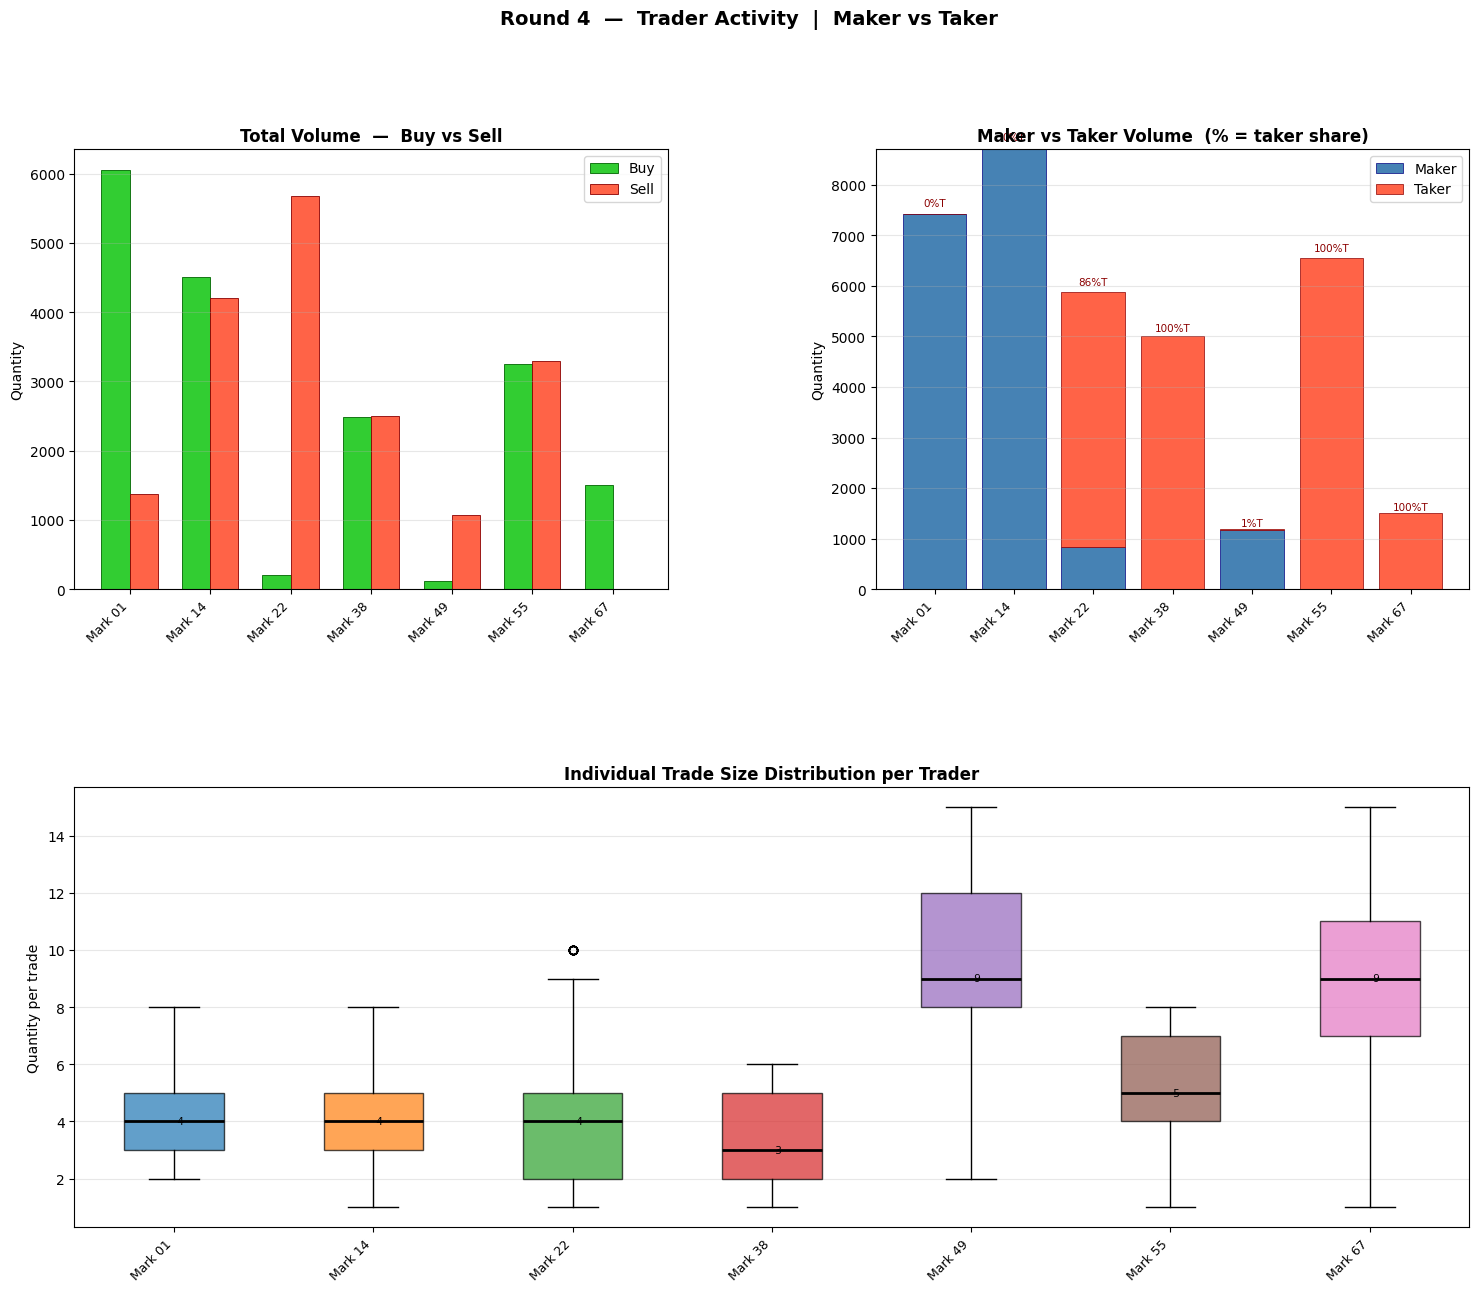


Trader      Buy Vol  Sell Vol    Maker    Taker   Taker%  Role
-----------------------------------------------------------------
Mark 01       6,053     1,375    7,428        0       0%  MAKER
Mark 14       4,510     4,208    8,708        0       0%  MAKER
Mark 22         206     5,683      825    5,054      86%  TAKER
Mark 38       2,493     2,507        0    5,000     100%  TAKER
Mark 49         115     1,071    1,169       17       1%  MAKER
Mark 55       3,254     3,297        0    6,551     100%  TAKER
Mark 67       1,510         0        1    1,509     100%  TAKER


In [18]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Infer Maker / Taker via price vs mid ─────────────────────────────────────
# For each trade, merge with the nearest mid_price (same day + product).
# price > mid  →  buyer crossed the ask  →  buyer = taker, seller = maker
# price < mid  →  seller crossed the bid →  seller = taker, buyer = maker
# price ≈ mid  →  ambiguous              →  both = mid

def tag_maker_taker(trades_df, prices_df, tol=0.01):
    pieces = []
    for (day, symbol), grp in trades_df.groupby(["day", "symbol"]):
        mid = prices_df[
            (prices_df["day"] == day) & (prices_df["product"] == symbol)
        ].sort_values("timestamp")[["timestamp", "mid_price"]]

        grp = grp.sort_values("timestamp").copy()
        if not mid.empty:
            grp = pd.merge_asof(grp, mid, on="timestamp", direction="nearest")
        else:
            grp["mid_price"] = np.nan

        def roles(row):
            m = row["mid_price"]
            if pd.isna(m):
                return "taker", "maker"
            if row["price"] > m + tol:
                return "taker", "maker"   # aggressive buy
            if row["price"] < m - tol:
                return "maker", "taker"   # aggressive sell
            return "mid", "mid"

        r = grp.apply(roles, axis=1, result_type="expand")
        r.columns = ["buyer_role", "seller_role"]
        pieces.append(pd.concat([grp, r], axis=1))

    return pd.concat(pieces, ignore_index=True)


tw = tag_maker_taker(trades, prices)

# ── Build per-trader summary ──────────────────────────────────────────────────
buy_vol  = tw.dropna(subset=["buyer_id"]).groupby("buyer_id")["quantity"].sum().rename("buy")
sell_vol = tw.dropna(subset=["seller_id"]).groupby("seller_id")["quantity"].sum().rename("sell")
vol_df   = pd.concat([buy_vol, sell_vol], axis=1).fillna(0)

def role_vol(df, id_col, role_col, role_val):
    return (
        df[df[role_col] == role_val]
        .dropna(subset=[id_col])
        .groupby(id_col)["quantity"]
        .sum()
    )

taker_as_buyer  = role_vol(tw, "buyer_id",  "buyer_role",  "taker")
maker_as_buyer  = role_vol(tw, "buyer_id",  "buyer_role",  "maker")
taker_as_seller = role_vol(tw, "seller_id", "seller_role", "taker")
maker_as_seller = role_vol(tw, "seller_id", "seller_role", "maker")

mt_df = pd.DataFrame({
    "taker": taker_as_buyer.add(taker_as_seller, fill_value=0),
    "maker": maker_as_buyer.add(maker_as_seller, fill_value=0),
}).fillna(0)
mt_df["total"]        = mt_df["taker"] + mt_df["maker"]
mt_df["taker_pct"]    = 100 * mt_df["taker"] / mt_df["total"].replace(0, np.nan)
mt_df = mt_df.reindex(vol_df.index).fillna(0)

labels = [f"Mark {int(i):02d}" for i in vol_df.index]

# ── Individual trade sizes (for box plots) ────────────────────────────────────
all_sizes = {}
for tid in vol_df.index:
    sizes = pd.concat([
        tw[tw["buyer_id"]  == tid]["quantity"],
        tw[tw["seller_id"] == tid]["quantity"],
    ]).dropna().values
    all_sizes[int(tid)] = sizes

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])   # buy/sell volume
ax2 = fig.add_subplot(gs[0, 1])   # stacked maker/taker
ax3 = fig.add_subplot(gs[1, :])   # box plots

# ── Plot 1 : Buy vs Sell volume ───────────────────────────────────────────────
x     = np.arange(len(labels))
w     = 0.35
ax1.bar(x - w/2, vol_df["buy"],  w, label="Buy",  color="limegreen", edgecolor="darkgreen", lw=0.6)
ax1.bar(x + w/2, vol_df["sell"], w, label="Sell", color="tomato",    edgecolor="darkred",   lw=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax1.set_title("Total Volume  —  Buy vs Sell", fontweight="bold")
ax1.set_ylabel("Quantity"); ax1.legend(); ax1.grid(axis="y", alpha=0.3)

# ── Plot 2 : Maker vs Taker stacked bar ──────────────────────────────────────
ax2.bar(x, mt_df["maker"], label="Maker", color="steelblue",   edgecolor="navy",   lw=0.5)
ax2.bar(x, mt_df["taker"], bottom=mt_df["maker"],
        label="Taker", color="tomato", edgecolor="darkred", lw=0.5)

for i, (mk, tk, pct) in enumerate(zip(mt_df["maker"], mt_df["taker"], mt_df["taker_pct"])):
    total = mk + tk
    if total > 0:
        ax2.text(i, total + total * 0.015, f"{pct:.0f}%T",
                 ha="center", va="bottom", fontsize=7.5, color="darkred")

ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax2.set_title("Maker vs Taker Volume  (% = taker share)", fontweight="bold")
ax2.set_ylabel("Quantity"); ax2.legend(); ax2.grid(axis="y", alpha=0.3)

# ── Plot 3 : Box plots of individual trade sizes ──────────────────────────────
data    = [all_sizes[int(i)] for i in vol_df.index]
bp      = ax3.boxplot(data, patch_artist=True, showfliers=True,
                      medianprops=dict(color="black", lw=2))
colors3 = plt.get_cmap("tab10").colors
for patch, color in zip(bp["boxes"], colors3):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax3.set_xticks(np.arange(1, len(labels) + 1))
ax3.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax3.set_title("Individual Trade Size Distribution per Trader", fontweight="bold")
ax3.set_ylabel("Quantity per trade"); ax3.grid(axis="y", alpha=0.3)

for i, d in enumerate(data):
    if len(d):
        med = np.median(d)
        ax3.text(i + 1, med, f" {med:.0f}", va="center", fontsize=7.5, color="black")

fig.suptitle(f"Round {ROUND_NUMBER}  —  Trader Activity  |  Maker vs Taker", fontsize=14, fontweight="bold")
plt.show()

# ── Print maker/taker table ───────────────────────────────────────────────────
print(f"\n{'Trader':<10} {'Buy Vol':>8} {'Sell Vol':>9} {'Maker':>8} {'Taker':>8} {'Taker%':>8}  Role")
print("-" * 65)
for tid, lbl in zip(vol_df.index, labels):
    bv   = int(vol_df.loc[tid, "buy"])
    sv   = int(vol_df.loc[tid, "sell"])
    mk   = int(mt_df.loc[tid, "maker"])
    tk   = int(mt_df.loc[tid, "taker"])
    pct  = mt_df.loc[tid, "taker_pct"]
    role = "TAKER" if pct >= 60 else ("MAKER" if pct <= 40 else "MIXED")
    print(f"{lbl:<10} {bv:>8,} {sv:>9,} {mk:>8,} {tk:>8,} {pct:>7.0f}%  {role}")
